# Data preparation

## Importing data

In [26]:
from matplotlib.lines import lineStyles

from main import LinearRegressionFS
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
#df.head()


In [27]:
# Creating features and prediction feature
y = df[['addiction_level']]
x = df.drop(['addiction_level'], axis=1)
#x.head(100)

In [28]:
# one hot encoding
x_cat = x[['gender','platform_usage','social_interaction_level']]
x_cat_encoded = pd.get_dummies(x_cat)
x_num = x.drop(x_cat, axis=1)






## Data scaling
- Normalization
- Z-score normalization

In [29]:
# feature scaling (normalization)
x_num_normalized = (x_num - x_num.min()) / (x_num.max()-x_num.min())

#x_num_normalized.describe()

In [30]:
# feature scaling (z-score normalization)
x_num_zscore_normalized = (x_num - x_num.mean()) / (x_num.std())


#x_num_zscore_normalized.describe()

## Categorical and numerical data concatenation

In [31]:
# concat normalized x_num and concatenated x_cat
X= pd.concat([x_cat_encoded, x_num_zscore_normalized], axis=1)
#X.head()

# Model training with simple hyperparameters

In [59]:
# fitting linear regression, model training
ln_reg  = LinearRegressionFS(learning_rate=0.002, n_iterations=3000)

ln_reg.fit(X,y)

# Comparison between Scikit-learn and my model's weights

In [60]:
# Comparing my model's weights vs Scikit-learn's model's weights
print("My model's weights: \n" ,ln_reg.w)
from sklearn.linear_model import LinearRegression

line_reg = LinearRegression()
line_reg.fit(X,y)
print("Scikit-learn model's weights: \n",line_reg.coef_)
print("Scikit-learn model's intercept: \n",line_reg.intercept_)

My model's weights: 
    addiction_level
0         2.567319
1         1.210473
2         1.356845
3         0.796065
4         0.870691
5         0.900562
6         0.856073
7         0.779124
8         0.932121
9         0.102588
10       -0.069685
11       -0.168802
12        0.084706
13        0.096713
14        0.076564
15        0.013632
16        0.104602
17       -0.077188
Scikit-learn model's weights: 
 [[-0.07519589  0.07519589 -0.06379785  0.00965096  0.05414688  0.012935
  -0.09474009  0.0818051   0.10273757 -0.0690934  -0.17005087  0.08449917
   0.09720622  0.07665781  0.01433108  0.10504354 -0.07934586]]
Scikit-learn model's intercept: 
 [5.56307107]


# Visualization of cost history over iterations

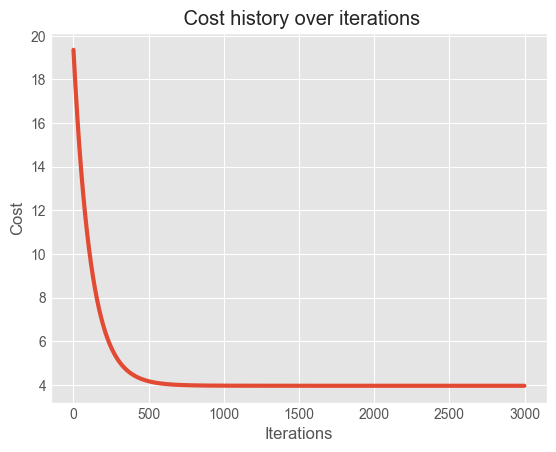

In [62]:
from matplotlib import pyplot as plt

plt.style.use('ggplot')

plt.title(" Cost history over iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")

# plt.figure(facecolor='white')
# ax = plt.gca()
# ax.set_facecolor('white')

plt.plot(ln_reg.cost_history, linewidth = 3)

plt.show()